**问题3分析：**
当当网销量排名前 50 的 Python 类书籍，哪些出版社的书籍比较多？

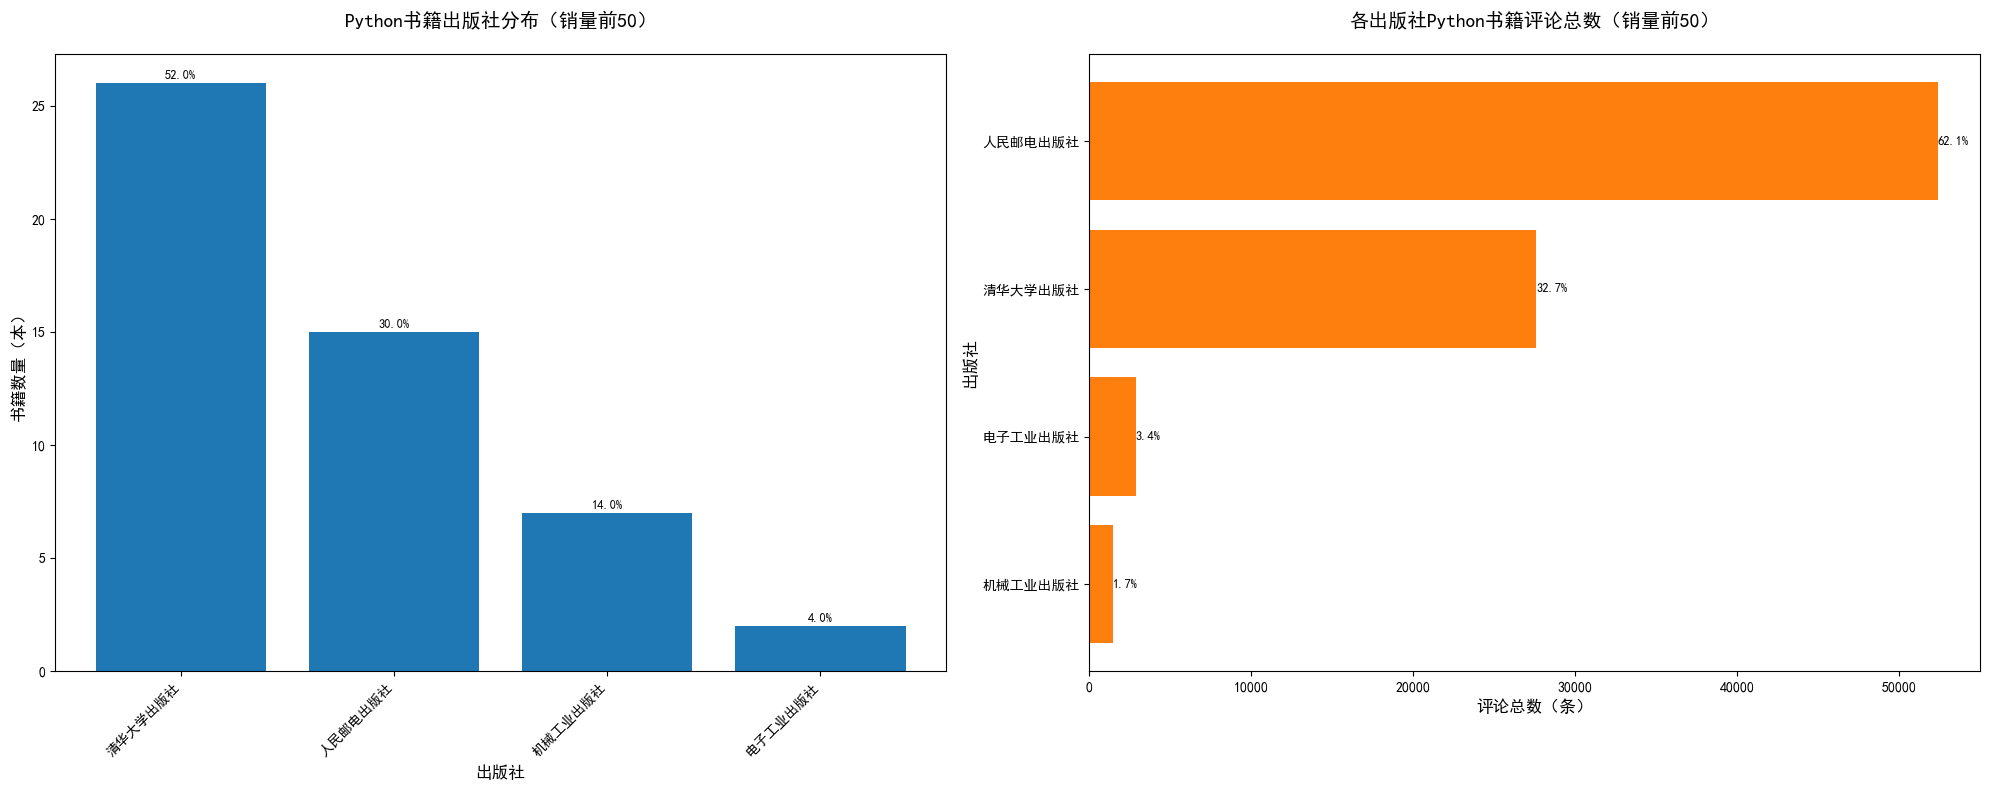

分析完成！结果已保存至：d:\course_pro\ex_Team01_Group_3\output\Tsk3
1. 合并图表：出版社统计合并图表.png
2. 分析数据：Python书籍出版社分析结果.csv

=== 结果解读 ===
1. 畅销数量排名靠前的清华大学出版社，一定程度上，说明其推出的Python书籍更易进入畅销榜单，市场发行和内容打磨能力更强。
2. 人民邮电出版社的畅销书数量低于清华大学出版社，但是总评论数高于清华大学出版社，说明其书籍内容更易引发读者共鸣、疑问或讨论，可能的原因有：入门类书籍读者提问多，实战类书籍读者分享经验多。这可以给作者写书方向作参考。


In [2]:
# =============================================================
# Tsk3 销量前 50 的 Python 类图书中销量较多的出版社
# 刘嘉亮25210193
# =============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

# -------------------------- 1. 数据读取与预处理 --------------------------
# 设置中文字体（解决中文显示乱码问题）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 定义文件路径
input_file = r"../data_clean/dangdang_python_books_clean.csv"
output_dir = os.path.abspath(r"../output/Tsk3")

# 创建输出目录（如果不存在）
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 读取CSV文件，仅提取指定三列
df = pd.read_csv(
    input_file,
    usecols=['书名', '出版社', '评论数']
)

# 数据清洗：确保评论数为数值类型，处理缺失值
df['评论数'] = pd.to_numeric(df['评论数'], errors='coerce').fillna(0).astype(int)

# -------------------------- 2. 统计数据（共用） --------------------------
# 统计出版社数量
press_freq = df['出版社'].value_counts()
press_pct = (press_freq / press_freq.sum()) * 100

# 统计出版社评论总数
press_comment = df.groupby('出版社')['评论数'].sum().sort_values(ascending=False)
comment_pct = (press_comment / press_comment.sum()) * 100

# -------------------------- 3. 两张图表合并为一张图展示（核心修改） --------------------------
# 创建 1行2列 的子图布局
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# ========= 子图1：出版社数量条形图 =========
bars1 = ax1.bar(press_freq.index, press_freq.values, color='#1f77b4')
ax1.set_title('Python书籍出版社分布（销量前50）', fontsize=14, pad=20)
ax1.set_xlabel('出版社', fontsize=12)
ax1.set_ylabel('书籍数量（本）', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.get_xticklabels(), ha='right')

# 数量百分比标注
for bar, pct in zip(bars1, press_pct):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# ========= 子图2：出版社评论总数水平条形图 =========
bars2 = ax2.barh(press_comment.index, press_comment.values, color='#ff7f0e')
ax2.set_title('各出版社Python书籍评论总数（销量前50）', fontsize=14, pad=20)
ax2.set_xlabel('评论总数（条）', fontsize=12)
ax2.set_ylabel('出版社', fontsize=12)
ax2.invert_yaxis()

# 评论百分比标注
for bar, pct in zip(bars2, comment_pct):
    width = bar.get_width()
    ax2.text(width + 5, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', ha='left', va='center', fontsize=9)

# 整体布局调整
plt.tight_layout()

# 保存合并后的图表（一张图包含两个子图）
fig.savefig(os.path.join(output_dir, '出版社统计合并图表.png'), dpi=300, bbox_inches='tight')

# -------------------------- 核心修改：先显示图表，关闭后再输出解读 --------------------------
# 显示图表（阻塞模式，关闭窗口后才会继续执行后续代码）
plt.show()

# -------------------------- 4. 保存分析结果数据 --------------------------
result_df = pd.DataFrame({
    '出版社': press_freq.index,
    '书籍数量': press_freq.values,
    '书籍数量占比(%)': press_pct.values.round(1),
    '评论总数': press_comment.reindex(press_freq.index).fillna(0).astype(int),
    '评论数占比(%)': comment_pct.reindex(press_freq.index).fillna(0).round(1)
})

result_df.to_csv(
    os.path.join(output_dir, 'Python书籍出版社分析结果.csv'),
    index=False,
    encoding='utf-8-sig'
)

# -------------------------- 5. 输出提示 --------------------------
print(f"分析完成！结果已保存至：{output_dir}")
print(f"1. 合并图表：出版社统计合并图表.png")
print(f"2. 分析数据：Python书籍出版社分析结果.csv")

print("\n=== 结果解读 ===")
print("1. 畅销数量排名靠前的清华大学出版社，一定程度上，说明其推出的Python书籍更易进入畅销榜单，市场发行和内容打磨能力更强。\n2. 人民邮电出版社的畅销书数量低于清华大学出版社，但是总评论数高于清华大学出版社，说明其书籍内容更易引发读者共鸣、疑问或讨论，可能的原因有：入门类书籍读者提问多，实战类书籍读者分享经验多。这可以给作者写书方向作参考。")